In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
import os

In [7]:
performance_statistics = pd.read_csv('unet-performance-statistics.csv', index_col = 0)

In [8]:
unaugmented_performance = performance_statistics[performance_statistics['num_synthetic_images'] == 0]
augmented_performance = performance_statistics[performance_statistics['num_synthetic_images'] > 0]

In [9]:
performance_statistics

,num_subjects,num_real_images,num_synthetic_images,synthetic_to_real_ratio,unet_training_min_loss,unet_validation_peak_accuracy,unet_validation_min_loss
0,9,534,0,0.000000,0.2272,0.0328,0.3114
1,9,534,2120,3.970037,0.0433,0.0320,0.0855
2,18,1158,0,0.000000,0.0595,0.0117,0.0882
3,18,1158,4560,3.937824,0.0081,0.2017,0.0703
4,27,1802,0,0.000000,0.0387,0.4138,0.0544
5,27,1802,4928,2.734739,0.0094,0.5062,0.0400
6,37,2306,0,0.000000,0.0449,0.4743,0.0564
7,37,2306,4928,2.137034,0.0081,0.5987,0.0325
8,47,2854,0,0.000000,0.0348,0.5150,0.0459
9,47,2854,4928,1.726699,0.0061,0.6176,0.0271


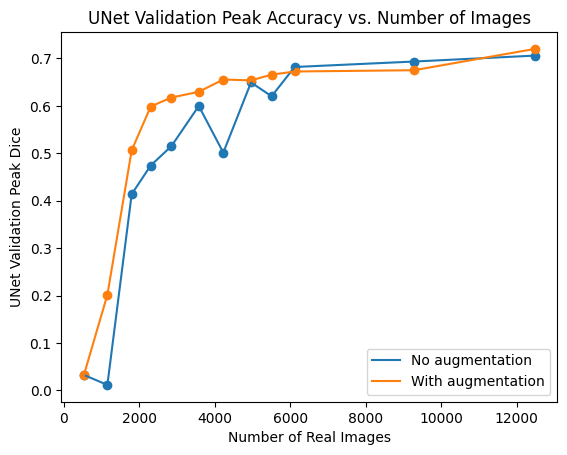

In [7]:
plt.plot(unaugmented_performance['num_real_images'].values, unaugmented_performance['unet_validation_peak_accuracy'].values, label="No augmentation")
plt.plot(augmented_performance['num_real_images'].values, augmented_performance['unet_validation_peak_accuracy'].values, label="With augmentation")
plt.title('UNet Validation Peak Accuracy vs. Number of Images')
plt.scatter(unaugmented_performance['num_real_images'].values, unaugmented_performance['unet_validation_peak_accuracy'].values)
plt.scatter(augmented_performance['num_real_images'].values, augmented_performance['unet_validation_peak_accuracy'].values)
plt.title('UNet Validation Peak Accuracy vs. Number of Images')
plt.legend()
plt.xlabel('Number of Real Images')
plt.ylabel('UNet Validation Peak Dice')
plt.show()

In [18]:
augmented_performance.columns = ['num_unique_case_day_combos'] + list(augmented_performance.columns[1:])

In [19]:
augmented_performance

,num_unique_case_day_combos,num_real_images,num_synthetic_images,synthetic_to_real_ratio,unet_training_min_loss,unet_validation_peak_accuracy,unet_validation_min_loss
1,10,706,2800,3.966006,0.0687,0.0000,0.1013
3,18,1176,4640,3.945578,0.0341,0.0000,0.0807
5,27,1718,4928,2.868452,0.0550,0.0000,0.0823
7,37,2430,4928,2.027984,0.0170,0.2568,0.0459
9,47,3144,4928,1.567430,0.0133,0.3663,0.0353
11,57,3704,4928,1.330454,0.0132,0.4421,0.0260
13,67,4170,4928,1.181775,0.0149,0.4645,0.0275
15,77,4968,4928,0.991948,0.0122,0.5062,0.0251
17,87,5436,4928,0.906549,0.0125,0.5388,0.0242
19,97,6050,4928,0.814545,0.0124,0.5652,0.0226


In [6]:
import numpy as np

In [35]:
np.sum(augmented_performance['unet_validation_peak_accuracy'].values > unaugmented_performance['unet_validation_peak_accuracy'].values)

np.int64(6)

In [36]:
np.sum(augmented_performance['unet_validation_peak_accuracy'].values < unaugmented_performance['unet_validation_peak_accuracy'].values)

np.int64(5)

In [42]:
np.sum(augmented_performance['unet_validation_peak_accuracy'].values == unaugmented_performance['unet_validation_peak_accuracy'].values)

np.int64(1)

In [43]:
# Confirm that none of the synthesis images are used in the validation set

In [7]:
evaluation_results_original = pd.read_csv('evaluation_results_original.csv')
high_quality_images = evaluation_results_original[evaluation_results_original['SSIM'] > 0.5]

high_quality_image_case_day = [image for image in high_quality_images['Image'].values.tolist()]

In [9]:
synthesis_case_days = set([image.split('_slice')[0] for image in high_quality_image_case_day])

In [14]:

train_set_case_days = pd.read_csv('train_set_case_days.csv')['0'].values.tolist()

In [15]:
val_set_case_days = pd.read_csv('val_set_case_days.csv')['0'].values.tolist()

In [ ]:
[case_day for case_day in val_set_case_days if case_day in synthesis_case_days]
# Confirms that none of the syntheis images are used in the validation set

[]

In [19]:
synthesis_case_days

{'case102_day0',
 'case113_day12',
 'case113_day19',
 'case114_day0',
 'case114_day17',
 'case116_day0',
 'case131_day0',
 'case131_day19',
 'case133_day25',
 'case134_day0',
 'case148_day20',
 'case18_day0',
 'case19_day0',
 'case19_day14',
 'case2_day2',
 'case49_day0',
 'case49_day13',
 'case78_day18',
 'case90_day29'}

In [20]:
val_set_case_days

['case108_day13',
 'case101_day26',
 'case74_day0',
 'case41_day0',
 'case30_day0',
 'case67_day12',
 'case89_day21',
 'case15_day0',
 'case36_day6',
 'case88_day36',
 'case32_day20',
 'case101_day22',
 'case133_day23',
 'case154_day17',
 'case133_day0',
 'case33_day0',
 'case77_day20',
 'case130_day22',
 'case63_day18',
 'case84_day21',
 'case81_day0',
 'case63_day0',
 'case35_day13',
 'case2_day4',
 'case85_day23',
 'case35_day18',
 'case154_day14',
 'case147_day19',
 'case58_day0',
 'case88_day38',
 'case81_day30',
 'case118_day14',
 'case138_day12',
 'case143_day23',
 'case36_day0',
 'case118_day16',
 'case35_day12',
 'case136_day0',
 'case84_day23',
 'case34_day16',
 'case107_day0',
 'case131_day15',
 'case65_day25',
 'case129_day22',
 'case108_day10',
 'case40_day0',
 'case2_day5',
 'case44_day0',
 'case142_day16',
 'case131_day21',
 'case67_day0']

In [47]:
val_set_case_days

['case108_day13',
 'case101_day26',
 'case74_day0',
 'case41_day0',
 'case30_day0',
 'case67_day12',
 'case89_day21',
 'case15_day0',
 'case36_day6',
 'case88_day36',
 'case32_day20',
 'case101_day22',
 'case133_day23',
 'case154_day17',
 'case133_day0',
 'case33_day0',
 'case77_day20',
 'case130_day22',
 'case63_day18',
 'case84_day21',
 'case81_day0',
 'case63_day0',
 'case35_day13',
 'case2_day4',
 'case85_day23',
 'case35_day18',
 'case154_day14',
 'case147_day19',
 'case58_day0',
 'case88_day38',
 'case81_day30',
 'case118_day14',
 'case138_day12',
 'case143_day23',
 'case36_day0',
 'case118_day16',
 'case35_day12',
 'case136_day0',
 'case84_day23',
 'case34_day16',
 'case107_day0',
 'case131_day15',
 'case65_day25',
 'case129_day22',
 'case108_day10',
 'case40_day0',
 'case2_day5',
 'case44_day0',
 'case142_day16',
 'case131_day21',
 'case67_day0']